In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Datasets/house_price_practice.csv')

In [8]:
df.head()

,area,bedrooms,age,location,price
0,1510.0,2.0,33.0,Suburb,72.0
1,1944.0,3.0,4.0,City,149.3
2,1780.0,2.0,33.0,City,98.8
3,1745.0,2.0,14.0,City,96.9
4,2288.0,4.0,21.0,City,170.0


In [10]:
df.shape

(100, 5)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      98 non-null     float64
 1   bedrooms  99 non-null     float64
 2   age       99 non-null     float64
 3   location  99 non-null     object 
 4   price     100 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.0+ KB


In [36]:
df.describe()

,area,bedrooms,age,price
count,98.000000,99.000000,99.000000,100.000000
mean,1963.346939,2.969697,20.959596,124.604000
std,722.824929,1.216003,10.305456,50.898256
min,671.000000,1.000000,1.000000,38.000000
25%,1414.500000,2.000000,13.500000,83.025000
50%,1934.500000,3.000000,22.000000,125.650000
75%,2687.500000,4.000000,30.000000,168.350000
max,3099.000000,5.000000,35.000000,210.000000


In [22]:
df.describe()

df.isnull().sum()

df['location'].value_counts()

location
City      54
Suburb    45
Name: count, dtype: int64

In [24]:
df.corr(numeric_only=True)

,area,bedrooms,age,price
area,1.000000,0.873418,0.023792,0.951859
bedrooms,0.873418,1.000000,-0.022162,0.890437
age,0.023792,-0.022162,1.000000,-0.120208
price,0.951859,0.890437,-0.120208,1.000000


In [27]:
df.groupby('location')['price'].mean()

location
City      131.144444
Suburb    114.857778
Name: price, dtype: float64

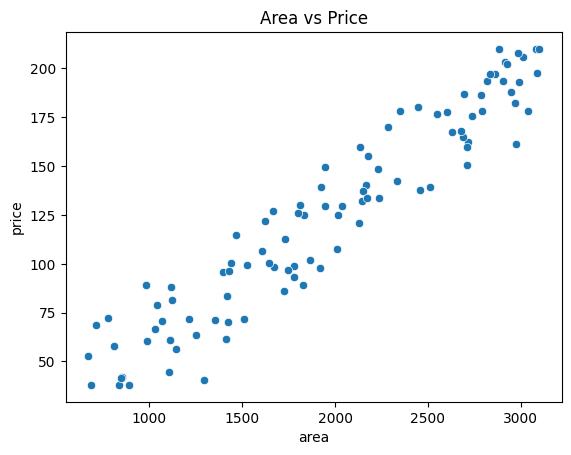

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=df,x='area' ,y='price')
plt.title('Area vs Price')
plt.show()

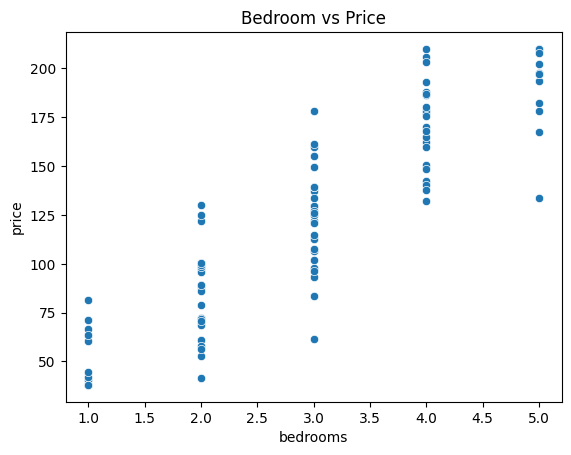

In [31]:
sns.scatterplot(data=df,x='bedrooms' ,y='price')
plt.title('Bedroom vs Price')
plt.show()

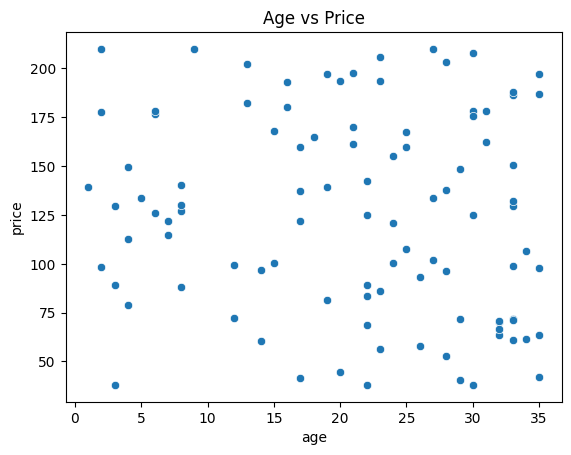

In [32]:
sns.scatterplot(data=df, x='age', y='price')
plt.title('Age vs Price')
plt.show()

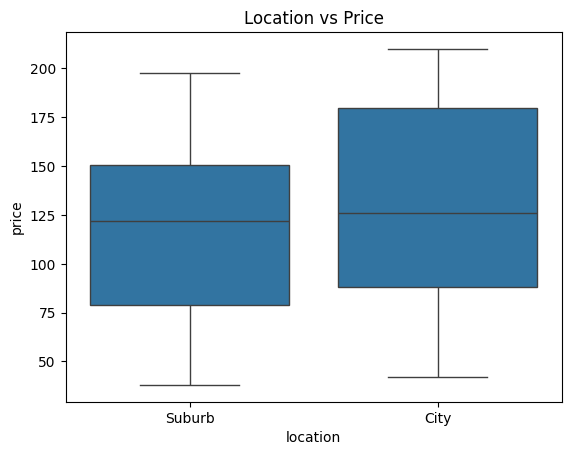

In [35]:
sns.boxplot(data=df, x='location', y='price')
plt.title('Location vs Price')
plt.show()
# Here the location is categorical so use of boxplot

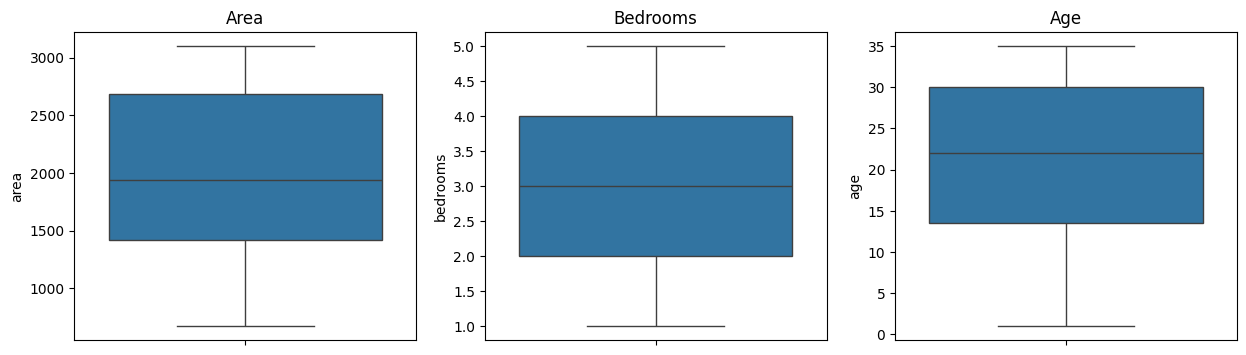

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=df['area'], ax=axes[0])
axes[0].set_title('Area')

sns.boxplot(y=df['bedrooms'], ax=axes[1])
axes[1].set_title('Bedrooms')

sns.boxplot(y=df['age'], ax=axes[2])
axes[2].set_title('Age')

plt.show()

In [42]:
from sklearn.model_selection import train_test_split

X = df[['area','location','bedrooms','age']]
y = df['price']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(80, 4)
(80,)
(20, 4)
(20,)


In [45]:
X_train.isnull().sum()

area        2
location    0
bedrooms    1
age         1
dtype: int64

In [47]:
X_test.isnull().sum()

area        0
location    1
bedrooms    0
age         0
dtype: int64

In [50]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numerical_features =[
    'area',
    'bedrooms',
    'age'
]

categorical_features = [
    'location']

numerical_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
])
categorical_transformer = Pipeline([
    ('imputer' ,SimpleImputer(strategy='most_frequent')),
     ('onehotencoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numerical_transformer , numerical_features),
    ('cat',categorical_transformer , categorical_features)
])

In [52]:
preprocessor.fit(X_train , y_train)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [54]:
print(preprocessor.named_transformers_['num']['imputer'].statistics_)
print(preprocessor.named_transformers_['cat']['imputer'].statistics_)

[1945.5    3.    22. ]
['City']


In [63]:
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)

In [65]:
print(X_train_trans.shape)
print(X_test_trans.shape)
print(X_train_trans)

(80, 5)
(20, 5)
[[1.7790e+03 3.0000e+00 2.6000e+01 0.0000e+00 1.0000e+00]
 [1.0410e+03 2.0000e+00 4.0000e+00 0.0000e+00 1.0000e+00]
 [1.7320e+03 3.0000e+00 4.0000e+00 0.0000e+00 1.0000e+00]
 [2.7110e+03 4.0000e+00 3.3000e+01 0.0000e+00 1.0000e+00]
 [2.9930e+03 4.0000e+00 1.6000e+01 1.0000e+00 0.0000e+00]
 [2.1650e+03 4.0000e+00 8.0000e+00 0.0000e+00 1.0000e+00]
 [1.2500e+03 1.0000e+00 3.2000e+01 1.0000e+00 0.0000e+00]
 [2.8320e+03 5.0000e+00 1.9000e+01 1.0000e+00 0.0000e+00]
 [2.1320e+03 3.0000e+00 1.7000e+01 1.0000e+00 0.0000e+00]
 [1.7260e+03 2.0000e+00 2.3000e+01 0.0000e+00 1.0000e+00]
 [7.8000e+02 2.0000e+00 1.2000e+01 1.0000e+00 0.0000e+00]
 [2.0400e+03 3.0000e+00 3.0000e+00 0.0000e+00 1.0000e+00]
 [2.1450e+03 4.0000e+00 3.3000e+01 0.0000e+00 1.0000e+00]
 [1.6250e+03 2.0000e+00 1.7000e+01 1.0000e+00 0.0000e+00]
 [2.4460e+03 4.0000e+00 1.6000e+01 1.0000e+00 0.0000e+00]
 [2.8190e+03 5.0000e+00 2.0000e+01 0.0000e+00 1.0000e+00]
 [1.1050e+03 1.0000e+00 2.0000e+01 0.0000e+00 1.0000e+00

In [67]:
preprocessor.get_feature_names_out

<bound method ColumnTransformer.get_feature_names_out of ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['area', 'bedrooms', 'age']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['location'])])>

## Linear Regression

Now that preprocessing is complete, we train a Linear Regression model using the **training data only**.

### Important points
- The model learns the coefficients from `X_train_trans` and `y_train`.
- We keep the test set separate because it should represent **unseen data** for final evaluation.
- Linear Regression tries to find the best-fitting linear relationship between the input features and the target (`price`).


In [ ]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
lr = LinearRegression()

# Train the model using ONLY the transformed training data.
# The model learns the coefficients that best fit the training data.
lr.fit(X_train_trans, y_train)


In [83]:
# Predict prices for the test set.
# These predictions are made on data the model did not train on.
y_pred = lr.predict(X_test_trans)

# Predict prices for the training set as well.
# We need this to compare training performance with test performance.
y_train_pred = lr.predict(X_train_trans)


## Train performance vs Test performance

We evaluate the model on **both** datasets.

- **Train performance:** how well the model fits data it learned from.
- **Test performance:** how well the model generalizes to unseen data.

A very large gap between train and test performance can be a warning sign of overfitting. A small gap suggests that the model is generalizing more consistently, although it should not be judged from this comparison alone.


In [84]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# R²: proportion of variation in price explained by the model.
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_pred))

# MSE: average squared prediction error.
# Larger errors are penalized more strongly because they are squared.
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_pred))

# MAE: average absolute prediction error.
# It is easier to interpret because it stays in the same units as price.
print("Test MAE:", mean_absolute_error(y_test, y_pred))


Train R²: 0.9732500468259954
Test R²: 0.9654058522710068
Train MSE: 68.1629826254958
Test MSE: 88.36393878602512
Test MAE: 6.671589355738727


### How to read these metrics

- **R²:** closer to 1 means the model explains more of the variation in the target.
- **MSE:** lower is better; it is measured in squared target units.
- **MAE:** lower is better and gives the average absolute error in the original target units.

For this dataset, compare the train and test values rather than looking at only one score.


## RMSE

RMSE is the square root of MSE, so it returns the error to the **same units as the target price**. Lower RMSE is better.


In [ ]:
import numpy as np

# RMSE = sqrt(MSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)


In [78]:
# Compare some actual prices with the model's predictions.
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

results.head(10)


,Actual,Predicted
0,126.2,115.555223
1,133.7,148.248857
2,60.4,43.505330
3,107.6,112.480724
4,164.9,163.949303
5,197.6,194.349549
6,52.9,52.512007
7,159.7,160.023189
8,186.6,179.305878
9,72.0,68.919586


In [85]:
# Residual = Actual - Predicted
# Positive residual  -> model underestimated the price.
# Negative residual  -> model overestimated the price.
# Residual of 0      -> prediction exactly matched the actual value.
residual = y_test - y_pred


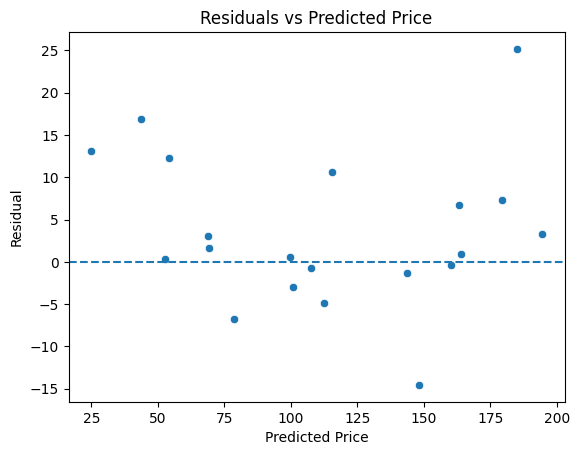

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot residuals against predicted prices to check whether errors
# show an obvious systematic pattern.
sns.scatterplot(x=y_pred, y=residual)

# Zero residual means Actual = Predicted.
# This is a reference line, NOT the Linear Regression best-fit line.
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted Price')
plt.show()


In [90]:
# Inspect the observations where the model made its largest errors.
residual_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'residual': residual
})

# Absolute error tells us the size of the error without caring about its direction.
residual_df['absolute_error'] = abs(residual_df['residual'])

residual_df.sort_values(
    'absolute_error',
    ascending=False
).head()


,actual,predicted,residual,absolute_error
76,210.0,184.838001,25.161999,25.161999
70,60.4,43.505330,16.894670,16.894670
53,133.7,148.248857,-14.548857,14.548857
30,38.0,24.881414,13.118586,13.118586
77,66.4,54.175987,12.224013,12.224013
